# MMM Stress Test #2 — Always-On / Low Variation

> **Can MMM measure a channel whose spend barely changes week to week?**

This notebook runs a controlled synthetic experiment to answer that question directly.

**Setup:**
- 156 weeks of synthetic marketing data
- 3 channels: Meta, Search, TV
- True ROAS is known exactly for every simulation (Meta=2.0, Search=5.0, TV=1.5)
- Revenue includes trend, seasonality, and promotions
- We fit the simplest correct model: OLS with the right controls
- We repeat 300 simulations per condition

**Stress variable:** Search spend coefficient of variation (CV = standard deviation / mean)

- **High CV (0.50):** Search spend varies a lot week to week — easy to identify its effect
- **Low CV (0.02):** Search spend is nearly flat every week — very hard to identify its effect

**Purpose:** Isolate the identification problem caused by always-on or flat-spend channels. Meta and TV retain full variation throughout. Only Search spend variability changes. Everything else — true ROAS values, noise, baseline structure, number of weeks — remains identical across conditions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm

pd.set_option('display.float_format', '{:,.4f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 1. Configuration

The single stress variable in this experiment is the **coefficient of variation (CV)** of Search spend.

CV = standard deviation / mean. It controls how much Search spend fluctuates relative to its average level.

| CV level | What it means |
|---|---|
| 0.50 | Search spend swings widely — ±50% of mean per week |
| 0.30 | Moderate variation — still identifiable |
| 0.20 | Below typical real-world budgets |
| 0.10 | Low variation — budget is fairly flat |
| 0.05 | Very low — nearly always-on |
| 0.02 | Essentially constant — model has almost nothing to learn from |

**All else stays constant:** Meta and TV retain full variation. True ROAS values, noise level, baseline, and number of weeks are identical across all conditions.

In [2]:
N_WEEKS = 156

TRUE_ROAS = {
    "meta": 2.0,
    "search": 5.0,
    "tv": 1.5,
}

NOISE_SD = 60_000

CV_LEVELS = [0.50, 0.30, 0.20, 0.10, 0.05, 0.02]

print(f"N_WEEKS      : {N_WEEKS}")
print(f"TRUE_ROAS    : {TRUE_ROAS}")
print(f"NOISE_SD     : {NOISE_SD:,}")
print(f"CV_LEVELS    : {CV_LEVELS}")

N_WEEKS      : 156
TRUE_ROAS    : {'meta': 2.0, 'search': 5.0, 'tv': 1.5}
NOISE_SD     : 60,000
CV_LEVELS    : [0.5, 0.3, 0.2, 0.1, 0.05, 0.02]


## 2. Generate synthetic marketing data

**Revenue formula:**

```
Revenue = Baseline + 2.0 * meta_spend + 5.0 * search_spend + 1.5 * tv_spend + noise
```

where:

```
Baseline = 2,000,000 + 4,000*t + 500,000*sin(2πt/52) + 150,000*cos(2πt/52) + 400,000*promo
```

**Spend generation:**
- **Meta:** `clip(55,000 + 22,000 * normal_shock, 5,000, None)` — full variation always
- **Search:** `clip(42,000 + 42,000 * CV * normal_shock, 5,000, None)` — variation controlled by CV
- **TV:** `clip(90,000 + 45,000 * normal_shock, 0, None)` — full variation always, independent

At `cv=0.02`, Search spend barely moves from its mean of £42,000/week. The standard deviation of spend is only £840 — a range of roughly £41,000 to £43,000 each week. The model sees almost no contrast to learn from.

In [3]:
def generate_data(cv=0.50, seed=42, n_weeks=N_WEEKS, noise_sd=NOISE_SD):
    """Generate synthetic MMM dataset with controllable Search spend CV."""
    rng = np.random.default_rng(seed)

    t = np.arange(n_weeks)

    # Promotions: ~12% of weeks
    promo = rng.binomial(1, 0.12, size=n_weeks).astype(float)

    # Seasonality
    sin52 = np.sin(2 * np.pi * t / 52)
    cos52 = np.cos(2 * np.pi * t / 52)

    # Baseline revenue
    baseline = (
        2_000_000
        + 4_000 * t
        + 500_000 * sin52
        + 150_000 * cos52
        + 400_000 * promo
    )

    # Meta spend — full variation, independent
    meta_shocks = rng.normal(size=n_weeks)
    meta_spend = np.clip(55_000 + 22_000 * meta_shocks, 5_000, None)

    # Search spend — variation controlled by cv parameter
    search_raw = rng.normal(size=n_weeks)
    search_spend = np.clip(42_000 + 42_000 * cv * search_raw, 5_000, None)

    # TV spend — full variation, independent
    tv_spend = np.clip(90_000 + 45_000 * rng.normal(size=n_weeks), 0, None)

    # Noise
    noise = rng.normal(0, noise_sd, size=n_weeks)

    # Revenue
    revenue = (
        baseline
        + TRUE_ROAS["meta"] * meta_spend
        + TRUE_ROAS["search"] * search_spend
        + TRUE_ROAS["tv"] * tv_spend
        + noise
    )

    # True incremental revenue per channel
    true_meta_incremental = TRUE_ROAS["meta"] * meta_spend
    true_search_incremental = TRUE_ROAS["search"] * search_spend
    true_tv_incremental = TRUE_ROAS["tv"] * tv_spend

    df = pd.DataFrame({
        "week": t,
        "revenue": revenue,
        "baseline": baseline,
        "meta_spend": meta_spend,
        "search_spend": search_spend,
        "tv_spend": tv_spend,
        "promo": promo,
        "trend": t.astype(float),
        "sin52": sin52,
        "cos52": cos52,
        "true_meta_incremental": true_meta_incremental,
        "true_search_incremental": true_search_incremental,
        "true_tv_incremental": true_tv_incremental,
    })

    return df

## 3. Inspect one clean dataset

Before running the stress test, inspect the data at `cv=0.50` — the high-variation (easy) condition.

We verify:
- True ROAS values match configuration
- Channel spend correlations are modest (as intended)
- Spend ranges look plausible
- Actual CV matches the parameter

=== First 5 rows ===


,week,revenue,baseline,meta_spend,search_spend,tv_spend,promo,trend,sin52,cos52,true_meta_incremental,true_search_incremental,true_tv_incremental
0,0,"2,722,606.1909","2,150,000.0000","53,816.7839","66,725.6497","76,806.3786",0.0000,0.0000,0.0000,1.0000,"107,633.5678","333,628.2483","115,209.5679"
1,1,"2,885,650.8361","2,213,174.6712","93,894.4581","51,220.8203","177,175.4023",0.0000,1.0000,0.1205,0.9927,"187,788.9162","256,104.1013","265,763.1035"
2,2,"3,020,067.0390","2,273,299.1048","57,866.0395","78,622.6250","139,769.7016",0.0000,2.0000,0.2393,0.9709,"115,732.0789","393,113.1252","209,654.5525"
3,3,"2,776,941.4089","2,329,554.8799","76,620.2692","51,218.8563","46,705.8998",0.0000,3.0000,0.3546,0.9350,"153,240.5385","256,094.2817","70,058.8496"
4,4,"2,899,921.7633","2,381,179.9899","44,015.4968","59,387.7517","105,646.8804",0.0000,4.0000,0.4647,0.8855,"88,030.9937","296,938.7586","158,470.3205"



=== Spend correlation matrix ===
              meta_spend  search_spend  tv_spend
meta_spend        1.0000       -0.0420   -0.0140
search_spend     -0.0420        1.0000   -0.0020
tv_spend         -0.0140       -0.0020    1.0000

=== Search spend variation ===
  mean  : £42,414
  std   : £20,262
  actual CV : 0.4777  (target: 0.50)

=== True ROAS (from known coefficients) ===


,channel,true_roas,total_spend_£,total_incremental_£,implied_roas
0,meta,2.0000,"8,619,799.6063","17,239,599.2126",2.0000
1,search,5.0000,"6,616,549.5844","33,082,747.9221",5.0000
2,tv,1.5000,"13,738,449.6821","20,607,674.5231",1.5000


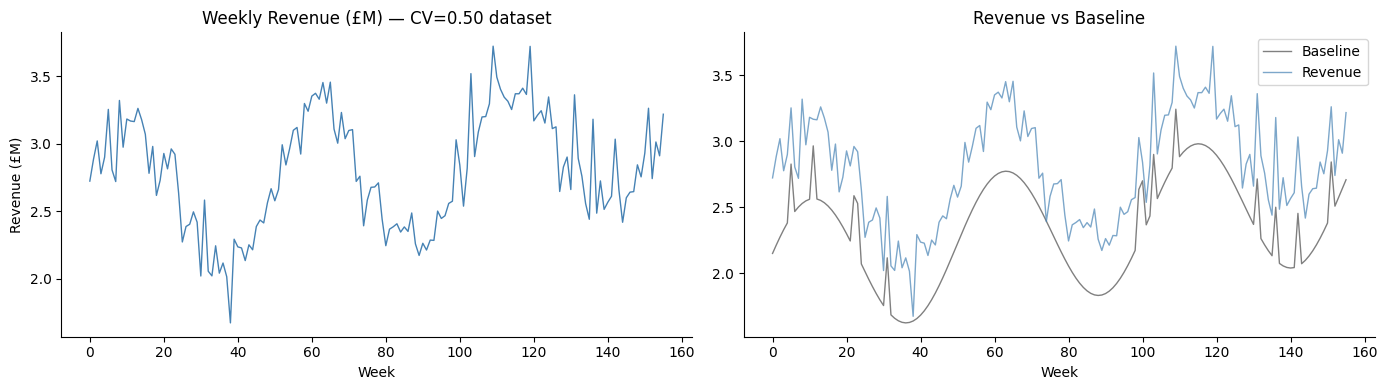

In [4]:
clean_df = generate_data(cv=0.50, seed=42)

print("=== First 5 rows ===")
display(clean_df.head())

print("\n=== Spend correlation matrix ===")
print(clean_df[["meta_spend", "search_spend", "tv_spend"]].corr().round(3))

print("\n=== Search spend variation ===")
print(f"  mean  : £{clean_df['search_spend'].mean():,.0f}")
print(f"  std   : £{clean_df['search_spend'].std():,.0f}")
print(f"  actual CV : {clean_df['search_spend'].std() / clean_df['search_spend'].mean():.4f}  (target: 0.50)")

print("\n=== True ROAS (from known coefficients) ===")
truth_rows = []
for ch in ["meta", "search", "tv"]:
    total_spend = clean_df[f"{ch}_spend"].sum()
    total_incr = clean_df[f"true_{ch}_incremental"].sum()
    truth_rows.append({
        "channel": ch,
        "true_roas": TRUE_ROAS[ch],
        "total_spend_£": total_spend,
        "total_incremental_£": total_incr,
        "implied_roas": total_incr / total_spend,
    })
display(pd.DataFrame(truth_rows))

# Quick plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(clean_df["week"], clean_df["revenue"] / 1e6, color="steelblue", linewidth=1)
axes[0].set_title("Weekly Revenue (£M) — CV=0.50 dataset")
axes[0].set_xlabel("Week")
axes[0].set_ylabel("Revenue (£M)")

axes[1].plot(clean_df["week"], clean_df["baseline"] / 1e6, color="grey", linewidth=1, label="Baseline")
axes[1].plot(clean_df["week"], clean_df["revenue"] / 1e6, color="steelblue", linewidth=1, alpha=0.7, label="Revenue")
axes[1].set_title("Revenue vs Baseline")
axes[1].set_xlabel("Week")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Fit the simplest possible MMM

We fit OLS with the correct set of controls:
- **Media channels:** `meta_spend`, `search_spend`, `tv_spend`
- **Baseline controls:** `trend`, `sin52`, `cos52`, `promo`
- **Intercept:** included via `sm.add_constant`

The OLS coefficients on the spend variables are estimates of ROAS — directly comparable to the known true values.

This is the simplest correct model. No adstock, no saturation transformations. In Phase 1 of this series, the DGP is also linear with no adstock, so OLS is correctly specified.

In [5]:
def fit_model(df):
    """Fit OLS MMM with correct controls. Returns fitted model."""
    features = ["meta_spend", "search_spend", "tv_spend", "trend", "sin52", "cos52", "promo"]
    X = sm.add_constant(df[features])
    y = df["revenue"]
    model = sm.OLS(y, X).fit()
    return model


# Fit on clean dataset
clean_model = fit_model(clean_df)

print(f"R² = {clean_model.rsquared:.4f}")

# Build results table for single run
single_run_rows = []
for ch in ["meta", "search", "tv"]:
    col = f"{ch}_spend"
    coef = clean_model.params[col]
    ci_low = clean_model.conf_int(alpha=0.10).loc[col, 0]
    ci_high = clean_model.conf_int(alpha=0.10).loc[col, 1]
    true_roas = TRUE_ROAS[ch]
    single_run_rows.append({
        "channel": ch,
        "true_roas": true_roas,
        "estimated_roas": coef,
        "relative_error": abs(coef - true_roas) / true_roas,
        "ci_low_90": ci_low,
        "ci_high_90": ci_high,
        "covered_truth": ci_low <= true_roas <= ci_high,
    })

single_run_df = pd.DataFrame(single_run_rows)
print("\n=== Single run results (cv=0.50, seed=42) ===")
display(single_run_df)

R² = 0.9771

=== Single run results (cv=0.50, seed=42) ===


,channel,true_roas,estimated_roas,relative_error,ci_low_90,ci_high_90,covered_truth
0,meta,2.0000,1.6590,0.1705,1.2731,2.0450,True
1,search,5.0000,5.0700,0.0140,4.6464,5.4936,True
2,tv,1.5000,1.6011,0.0674,1.4060,1.7963,True


## 5. Do not trust one simulation

One simulation is not enough to draw conclusions. It shows us one possible outcome, but the model's behaviour depends on which specific noise draws it encountered.

To understand the **distribution** of outcomes — how reliable the model is across many possible datasets — we need Monte Carlo simulation.

**The logic:**
1. Fix the CV level
2. Generate 300 independent datasets (different random seeds)
3. Fit the model on each
4. Collect all 300 ROAS estimates per channel
5. Compute summary statistics: median, spread, coverage of true ROAS

We repeat this across all CV levels. This tells us not just whether one model estimate was accurate, but whether the approach is *reliably* accurate under each condition.

In [6]:
def run_one_simulation(cv, seed):
    """Generate data at given CV, fit model, return list of result rows (one per channel)."""
    df = generate_data(cv=cv, seed=seed)
    model = fit_model(df)

    actual_cv = df["search_spend"].std() / df["search_spend"].mean()
    r2 = model.rsquared

    rows = []
    for ch in ["meta", "search", "tv"]:
        col = f"{ch}_spend"
        coef = model.params[col]
        ci_low = model.conf_int(alpha=0.10).loc[col, 0]
        ci_high = model.conf_int(alpha=0.10).loc[col, 1]
        true_roas = TRUE_ROAS[ch]
        rows.append({
            "cv_target": cv,
            "actual_cv": actual_cv,
            "seed": seed,
            "channel": ch,
            "true_roas": true_roas,
            "estimated_roas": coef,
            "relative_error": abs(coef - true_roas) / true_roas,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "covered_truth": float(ci_low <= true_roas <= ci_high),
            "r2": r2,
        })
    return rows

## 6. Clean-case Monte Carlo (CV = 0.50, N = 500)

Before running the stress test, establish a **baseline** at the easy condition (CV=0.50).

This answers: when Search spend varies freely, how well does OLS recover all three ROAS values?

If the model fails even here, the stress test results are meaningless. We need to confirm the model works correctly under ideal conditions first.

In [7]:
N_CLEAN_SIMS = 500

print(f"Running {N_CLEAN_SIMS} simulations at cv=0.50 ...")
clean_rows = []
for sim_id in range(N_CLEAN_SIMS):
    seed = 100_000 + sim_id
    clean_rows.extend(run_one_simulation(cv=0.50, seed=seed))

clean_results = pd.DataFrame(clean_rows)

clean_scorecard = (
    clean_results
    .groupby("channel")
    .agg(
        true_roas=("true_roas", "first"),
        mean_estimated_roas=("estimated_roas", "mean"),
        median_relative_error=("relative_error", "median"),
        probability_over_50pct_error=("relative_error", lambda x: (x > 0.50).mean()),
        coverage_90pct=("covered_truth", "mean"),
        mean_r2=("r2", "mean"),
    )
    .reset_index()
)

print("\n=== Clean-case scorecard (cv=0.50, N=500) ===")
display(clean_scorecard)

Running 500 simulations at cv=0.50 ...

=== Clean-case scorecard (cv=0.50, N=500) ===


,channel,true_roas,mean_estimated_roas,median_relative_error,probability_over_50pct_error,coverage_90pct,mean_r2
0,meta,2.0000,2.0243,0.0711,0.0000,0.9160,0.9798
1,search,5.0000,5.0047,0.0310,0.0000,0.9220,0.9798
2,tv,1.5000,1.4968,0.0498,0.0000,0.9020,0.9798


## 7. The actual stress test — vary Search spend CV

Now run the core experiment. We reduce Search spend variability step by step, from CV=0.50 down to CV=0.02.

**What changes:** Only Search spend CV. Everything else is held constant.

**What we measure:** For each condition, across 300 simulations:
- How often does the model recover Search ROAS within 50% of truth?
- How does the uncertainty range (p10–p90) change?
- Do Meta and TV estimates degrade too, or stay stable?
- Does model fit (R²) give any warning that attribution is breaking down?

**Seed formula:** `200_000 + int(cv * 10_000) * 1_000 + simulation_id`

This ensures each (cv, simulation_id) pair gets a unique, reproducible seed.

In [8]:
N_STRESS_SIMS = 300

all_rows = []
for cv in CV_LEVELS:
    print(f"  cv={cv:.2f} — running {N_STRESS_SIMS} simulations ...")
    for sim_id in range(N_STRESS_SIMS):
        seed = 200_000 + int(cv * 10_000) * 1_000 + sim_id
        all_rows.extend(run_one_simulation(cv=cv, seed=seed))

stress_results = pd.DataFrame(all_rows)
print(f"\nTotal rows collected: {len(stress_results):,}")
print(f"Expected: {len(CV_LEVELS) * N_STRESS_SIMS * 3:,}  (cv_levels x sims x channels)")
print(stress_results[["cv_target", "channel", "estimated_roas"]].groupby(["cv_target", "channel"]).count())

  cv=0.50 — running 300 simulations ...
  cv=0.30 — running 300 simulations ...
  cv=0.20 — running 300 simulations ...
  cv=0.10 — running 300 simulations ...
  cv=0.05 — running 300 simulations ...
  cv=0.02 — running 300 simulations ...

Total rows collected: 5,400
Expected: 5,400  (cv_levels x sims x channels)
                   estimated_roas
cv_target channel                
0.0200    meta                300
          search              300
          tv                  300
0.0500    meta                300
          search              300
          tv                  300
0.1000    meta                300
          search              300
          tv                  300
0.2000    meta                300
          search              300
          tv                  300
0.3000    meta                300
          search              300
          tv                  300
0.5000    meta                300
          search              300
          tv                  300


## 8. Summarise the result

Aggregate across simulations for each (CV level, channel) combination.

Key metrics:
- **median_estimated_roas:** Central tendency — does OLS stay unbiased?
- **median_relative_error:** Typical error magnitude
- **probability_over_50pct_error:** How often does the model produce a wildly wrong estimate? This is the primary failure indicator.
- **coverage_90pct:** How often does the 90% CI contain the true ROAS? Should be ~90% if model is well-calibrated.
- **mean_r2:** Does overall fit degrade as attribution breaks?

In [9]:
stress_summary = (
    stress_results
    .groupby(["cv_target", "channel"])
    .agg(
        actual_cv=("actual_cv", "mean"),
        true_roas=("true_roas", "first"),
        median_estimated_roas=("estimated_roas", "median"),
        median_relative_error=("relative_error", "median"),
        probability_over_50pct_error=("relative_error", lambda x: (x > 0.50).mean()),
        coverage_90pct=("covered_truth", "mean"),
        mean_r2=("r2", "mean"),
    )
    .reset_index()
)

stress_summary["median_relative_error_pct"] = stress_summary["median_relative_error"] * 100
stress_summary["probability_over_50pct_error_pct"] = stress_summary["probability_over_50pct_error"] * 100
stress_summary["coverage_90pct_pct"] = stress_summary["coverage_90pct"] * 100

print("=== Stress test summary ===")
display(stress_summary)

=== Stress test summary ===


,cv_target,channel,actual_cv,true_roas,median_estimated_roas,median_relative_error,probability_over_50pct_error,coverage_90pct,mean_r2,median_relative_error_pct,probability_over_50pct_error_pct,coverage_90pct_pct
0,0.0200,meta,0.0200,2.0000,1.9908,0.0701,0.0000,0.9000,0.9787,7.0077,0.0000,90.0000
1,0.0200,search,0.0200,5.0000,4.6389,0.9053,0.7067,0.9100,0.9787,90.5338,70.6667,91.0000
2,0.0200,tv,0.0200,1.5000,1.5090,0.0493,0.0000,0.9133,0.9787,4.9265,0.0000,91.3333
3,0.0500,meta,0.0499,2.0000,1.9948,0.0780,0.0000,0.9033,0.9785,7.7985,0.0000,90.3333
4,0.0500,search,0.0499,5.0000,4.9563,0.3065,0.2900,0.8900,0.9785,30.6521,29.0000,89.0000
5,0.0500,tv,0.0499,1.5000,1.4878,0.0498,0.0000,0.8833,0.9785,4.9772,0.0000,88.3333
6,0.1000,meta,0.0999,2.0000,2.0035,0.0787,0.0000,0.8867,0.9789,7.8662,0.0000,88.6667
7,0.1000,search,0.0999,5.0000,5.0534,0.1595,0.0567,0.9033,0.9789,15.9488,5.6667,90.3333
8,0.1000,tv,0.0999,1.5000,1.5168,0.0481,0.0000,0.9167,0.9789,4.8105,0.0000,91.6667
9,0.2000,meta,0.2006,2.0000,1.9999,0.0739,0.0000,0.9200,0.9790,7.3879,0.0000,92.0000


## 9. Main chart — Search CV vs ROAS recovery probability

The core result of this experiment. For each CV level and channel, we plot the probability that the model produces a ROAS estimate more than 50% away from truth.

- **x-axis:** Search spend CV (reversed — high CV = easy, shown on left; low CV = hard, shown on right)
- **y-axis:** Probability of >50% relative error (lower is better)

We expect to see Search ROAS reliability collapse as CV falls. Meta and TV should stay stable because their spend variation is unchanged.

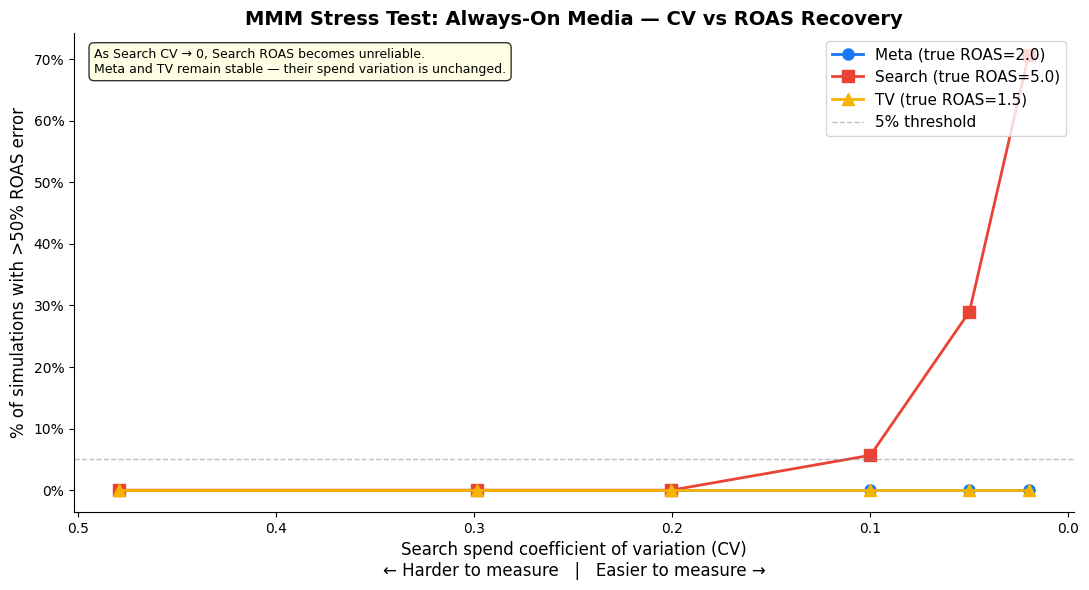

Chart saved: mmm_stress_test_02_main_chart.png


In [10]:
channel_styles = {
    "meta": {"color": "#1877F2", "marker": "o", "label": "Meta (true ROAS=2.0)"},
    "search": {"color": "#EA4335", "marker": "s", "label": "Search (true ROAS=5.0)"},
    "tv": {"color": "#F4B400", "marker": "^", "label": "TV (true ROAS=1.5)"},
}

fig, ax = plt.subplots(figsize=(11, 6))

for ch, style in channel_styles.items():
    ch_data = (
        stress_summary[stress_summary["channel"] == ch]
        .sort_values("actual_cv", ascending=False)
    )
    ax.plot(
        ch_data["actual_cv"],
        ch_data["probability_over_50pct_error_pct"],
        marker=style["marker"],
        color=style["color"],
        linewidth=2,
        markersize=8,
        label=style["label"],
    )

ax.set_xlim(ax.get_xlim()[::-1])  # Reverse x-axis: high CV (easy) on left
ax.axhline(5, color="grey", linestyle="--", linewidth=1, alpha=0.5, label="5% threshold")
ax.set_xlabel("Search spend coefficient of variation (CV)\n← Harder to measure   |   Easier to measure →", fontsize=12)
ax.set_ylabel("% of simulations with >50% ROAS error", fontsize=12)
ax.set_title("MMM Stress Test: Always-On Media — CV vs ROAS Recovery", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

note = "As Search CV → 0, Search ROAS becomes unreliable.\nMeta and TV remain stable — their spend variation is unchanged."
ax.text(0.02, 0.97, note, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig("mmm_stress_test_02_main_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: mmm_stress_test_02_main_chart.png")

## 10. Model fit chart — CV vs mean R²

One of the most important findings in this experiment: **R² barely changes as Search attribution collapses.**

This is a critical warning for practitioners. A high R² signals that the model explains revenue well overall. But it does not guarantee that individual channel ROAS estimates are accurate.

When Search spend barely varies, the model can still explain revenue through:
- The baseline trend and seasonality
- Meta and TV spend (which still vary)
- Promotions

Search ROAS estimation fails silently — R² gives no warning.

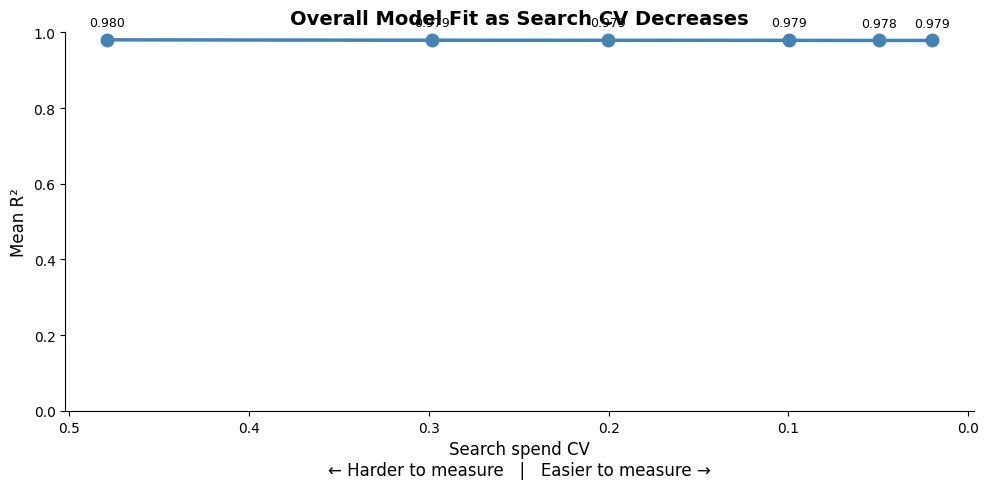


=== Model fit by CV level ===


,cv_target,actual_cv,mean_r2
5,0.5000,0.4793,0.9802
4,0.3000,0.2985,0.9791
3,0.2000,0.2006,0.9790
2,0.1000,0.0999,0.9789
1,0.0500,0.0499,0.9785
0,0.0200,0.0200,0.9787


In [11]:
fit_summary = (
    stress_results
    .groupby("cv_target")
    .agg(
        actual_cv=("actual_cv", "mean"),
        mean_r2=("r2", "mean"),
    )
    .reset_index()
    .sort_values("actual_cv", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    fit_summary["actual_cv"],
    fit_summary["mean_r2"],
    marker="o",
    color="steelblue",
    linewidth=2.5,
    markersize=9,
)
ax.set_xlim(ax.get_xlim()[::-1])  # Reverse: easy on left
ax.set_ylim(0, 1)
ax.set_xlabel("Search spend CV\n← Harder to measure   |   Easier to measure →", fontsize=12)
ax.set_ylabel("Mean R²", fontsize=12)
ax.set_title("Overall Model Fit as Search CV Decreases", fontsize=14, fontweight="bold")

for _, row in fit_summary.iterrows():
    ax.annotate(f"{row['mean_r2']:.3f}",
                xy=(row["actual_cv"], row["mean_r2"]),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("mmm_stress_test_02_r2_chart.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Model fit by CV level ===")
display(fit_summary)

## 11. ROAS uncertainty — how wide do the estimates become?

The probability-of-error metric captures failures, but doesn't show the full distribution. Here we look at the **spread** of ROAS estimates across simulations.

At high CV: the p10–p90 range should be narrow, centred on the true ROAS.

At low CV: the median may stay near the truth (OLS remains unbiased in expectation), but the p10–p90 range widens dramatically. Individual model fits become essentially random draws from a wide distribution.

This distinction matters: **bias vs variance.** The always-on problem is a variance problem, not a bias problem.

=== ROAS distribution summary (p10 / median / p90) ===


,cv_target,channel,actual_cv,true_roas,median_roas,p10_roas,p90_roas
0,0.0200,meta,0.0200,2.0000,1.9908,1.7114,2.2638
1,0.0200,search,0.0200,5.0000,4.6389,-2.8588,12.4855
2,0.0200,tv,0.0200,1.5000,1.5090,1.3580,1.6531
3,0.0500,meta,0.0499,2.0000,1.9948,1.7066,2.3355
4,0.0500,search,0.0499,5.0000,4.9563,1.9876,8.0689
5,0.0500,tv,0.0499,1.5000,1.4878,1.3616,1.6572
6,0.1000,meta,0.0999,2.0000,2.0035,1.7299,2.2985
7,0.1000,search,0.0999,5.0000,5.0534,3.5361,6.3935
8,0.1000,tv,0.0999,1.5000,1.5168,1.3881,1.6468
9,0.2000,meta,0.2006,2.0000,1.9999,1.7047,2.2921


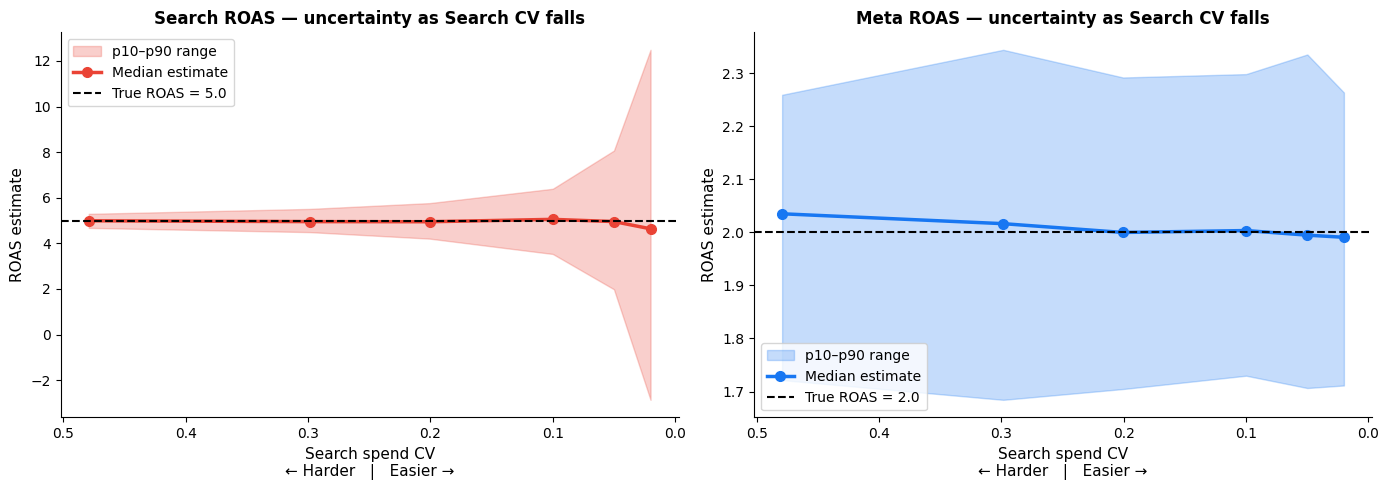

Chart saved: mmm_stress_test_02_roas_ribbon.png


In [12]:
roas_distribution_summary = (
    stress_results
    .groupby(["cv_target", "channel"])
    .agg(
        actual_cv=("actual_cv", "mean"),
        true_roas=("true_roas", "first"),
        median_roas=("estimated_roas", "median"),
        p10_roas=("estimated_roas", lambda x: np.quantile(x, 0.10)),
        p90_roas=("estimated_roas", lambda x: np.quantile(x, 0.90)),
    )
    .reset_index()
)

print("=== ROAS distribution summary (p10 / median / p90) ===")
display(roas_distribution_summary)

# Ribbon chart — Search and Meta comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ch, color in zip(axes, ["search", "meta"], ["#EA4335", "#1877F2"]):
    ch_data = (
        roas_distribution_summary[roas_distribution_summary["channel"] == ch]
        .sort_values("actual_cv", ascending=False)
    )
    true_roas_val = ch_data["true_roas"].iloc[0]

    ax.fill_between(
        ch_data["actual_cv"],
        ch_data["p10_roas"],
        ch_data["p90_roas"],
        alpha=0.25,
        color=color,
        label="p10–p90 range",
    )
    ax.plot(ch_data["actual_cv"], ch_data["median_roas"],
            color=color, linewidth=2.5, marker="o", markersize=7, label="Median estimate")
    ax.axhline(true_roas_val, color="black", linestyle="--", linewidth=1.5, label=f"True ROAS = {true_roas_val}")
    ax.set_xlim(ax.get_xlim()[::-1])
    ax.set_xlabel("Search spend CV\n← Harder   |   Easier →", fontsize=11)
    ax.set_ylabel("ROAS estimate", fontsize=11)
    ax.set_title(f"{ch.capitalize()} ROAS — uncertainty as Search CV falls", fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("mmm_stress_test_02_roas_ribbon.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: mmm_stress_test_02_roas_ribbon.png")

## 12. How to interpret the result

**Key findings from this experiment:**

1. **OLS remains unbiased in expectation even at very low CV.** Across 300 simulations at CV=0.02, the median Search ROAS estimate is still close to 5.0. The model is not systematically wrong. It is unreliable.

2. **But individual models become wildly unreliable.** The p10–p90 range at CV=0.02 is extremely wide. A single model run could produce almost any estimate. This is a variance problem, not a bias problem.

3. **Meta and TV stay stable.** Their spend variation is unchanged across conditions, so the model can still identify their effects reliably. The failure is specific to the always-on channel.

4. **Model fit (R²) stays high.** R² barely changes as Search attribution collapses. The model continues to explain revenue through baseline structure, Meta, and TV. R² is not a reliable signal of attribution quality.

5. **The root cause is a data problem, not a model problem.** OLS is correctly specified here. The model is doing exactly what it should. But when spend barely varies, there is no contrast in the data for the model to learn from. The coefficient is weakly identified — any value near zero is nearly as consistent with the data as the true value.

6. **In a Bayesian MMM, this is where priors dominate.** When the data provides little information, the posterior reverts toward the prior. A strong, well-calibrated prior can give reasonable estimates. A poorly calibrated prior gives wrong-but-confident estimates. This is the subject of Experiment 03.

**The core lesson:** Low spend variation is not a problem with the model. It is a data problem. The channel is not generating enough contrast for the model to learn from. The solution is not a better model — it is better data, or better experimental design (pulsing).

## 13. Save results to CSV

In [13]:
stress_results.to_csv("mmm_stress_test_02_raw_results.csv", index=False)
stress_summary.to_csv("mmm_stress_test_02_summary.csv", index=False)

print(f"Saved: mmm_stress_test_02_raw_results.csv  ({len(stress_results):,} rows)")
print(f"Saved: mmm_stress_test_02_summary.csv  ({len(stress_summary):,} rows)")

Saved: mmm_stress_test_02_raw_results.csv  (5,400 rows)
Saved: mmm_stress_test_02_summary.csv  (18 rows)
